In [75]:
# ==============================
# Set c configuration
# ==============================
CSV_PATH = "data/raw/set_b.csv"
NUMERIC_COLS = ['distance', 'load', 'traffic', 'staff']
TARGET = "late"
STAT_FEATURE = "distance"
COV_FEATURES = ['distance', 'load']

# Common exam settings
RANDOM_STATE = 42

print(CSV_PATH)
print(NUMERIC_COLS)
print(TARGET)

data/raw/set_b.csv
['distance', 'load', 'traffic', 'staff']
late


In [93]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, silhouette_score
)

In [77]:
rng = np.random.default_rng(202)
n = 300

cols = ['distance', 'load', 'traffic', 'staff']
x = rng.normal(size=(n, 4))

group = rng.choice(["G1", "G2"], size=n)

score = x @ np.array([0.6, 0.9, 1.2, -0.8])
score += 0.4 * (group == "G2") + rng.normal(0, 1, n)

y = (score > 0).astype(int)

df = pd.DataFrame(np.round(50 + 10*x, 2), columns=cols)
df.insert(0, "record_id", np.arange(1, n+1))
df["group"] = group
df["late"] = y

for col in cols[:2]:
    df.loc[rng.choice(n, 15, replace=False), col] = np.nan

df = pd.concat([df, df.iloc[:5]], ignore_index=True)

Path("data/raw").mkdir(parents=True, exist_ok=True)
df.to_csv("data/raw/set_b.csv", index=False)

print("Set B dataset created successfully!")
print("Dataset shape:", df.shape)
print("Saved at: data/raw/set_c.csv")


Set B dataset created successfully!
Dataset shape: (305, 7)
Saved at: data/raw/set_c.csv


In [78]:
for folder in [
    "outputs/figures", "outputs/metrics", "outputs/predictions",
    "outputs/clustering", "models"
]:
    Path(folder).mkdir(parents=True, exist_ok=True)

## csv path

In [79]:
CSV_PATH = "data/raw/set_c.csv"

In [80]:
df_raw = pd.read_csv(CSV_PATH)


## Data information

In [81]:
df_raw.shape

(305, 7)

In [82]:
df_raw.head(10)

,record_id,distance,load,traffic,staff,group,late
0,1,68.12,42.71,39.14,45.98,G2,1
1,2,38.47,65.08,58.80,56.38,G1,1
2,3,64.10,43.99,36.86,53.47,G2,0
3,4,53.09,41.44,55.36,64.72,G1,1
4,5,44.67,51.95,53.44,54.86,G1,1
5,6,60.23,NaN,64.00,41.90,G1,1
6,7,45.28,58.20,45.58,44.40,G2,1
7,8,49.55,53.52,45.02,55.93,G2,0
8,9,63.88,32.16,27.13,57.53,G2,0
9,10,42.04,64.56,78.69,48.58,G1,1


In [83]:
df_raw.columns.tolist()

['record_id', 'distance', 'load', 'traffic', 'staff', 'group', 'late']

In [84]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   record_id  305 non-null    int64  
 1   distance   290 non-null    float64
 2   load       290 non-null    float64
 3   traffic    305 non-null    float64
 4   staff      305 non-null    float64
 5   group      305 non-null    str    
 6   late       305 non-null    int64  
dtypes: float64(4), int64(2), str(1)
memory usage: 16.8 KB


In [85]:
df_raw.isnull().sum()

record_id     0
distance     15
load         15
traffic       0
staff         0
group         0
late          0
dtype: int64

In [86]:
print("\nTarget counts:")
display(df_raw[TARGET].value_counts())


Target counts:


late
0    156
1    149
Name: count, dtype: int64

In [87]:
df_raw.duplicated().sum()

np.int64(5)

#  Keep the original CSV unchanged.

In [88]:
df = df.drop_duplicates().reset_index(drop=True)

print("Rows before:", len(df_raw))
print("Rows after:", len(df))
print("Duplicates removed:", len(df_raw) - len(df))

assert len(df) == 300
assert df["record_id"].nunique() == 300

Rows before: 305
Rows after: 300
Duplicates removed: 5


In [89]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df[TARGET],
    random_state=RANDOM_STATE
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Test:", len(test_df))

assert len(train_df) == 240
assert len(test_df) == 60
assert set(train_df.record_id).isdisjoint(set(test_df.record_id))

Train: 240
Test: 60


In [90]:
print("Train:", len(train_df))
print("Test:", len(test_df))

Train: 240
Test: 60


## ANN Fit/validation

In [91]:
fit_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    stratify=train_df[TARGET],
    random_state=RANDOM_STATE
)

fit_df = fit_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Fit:", len(fit_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

assert len(fit_df) == 192
assert len(val_df) == 48
assert len(test_df) == 60

fit_ids = set(fit_df.record_id)
val_ids = set(val_df.record_id)
test_ids = set(test_df.record_id)

assert fit_ids.isdisjoint(val_ids)
assert fit_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)

splits = pd.concat([
    fit_df[["record_id"]].assign(partition="fit"),
    val_df[["record_id"]].assign(partition="validation"),
    test_df[["record_id"]].assign(partition="test")
])
splits.to_csv("outputs/splits.csv", index=False)
display(splits.head())

Fit: 192
Validation: 48
Test: 60


,record_id,partition
0,289,fit
1,74,fit
2,260,fit
3,281,fit
4,244,fit


## 5. M1 - Descriptive statistics

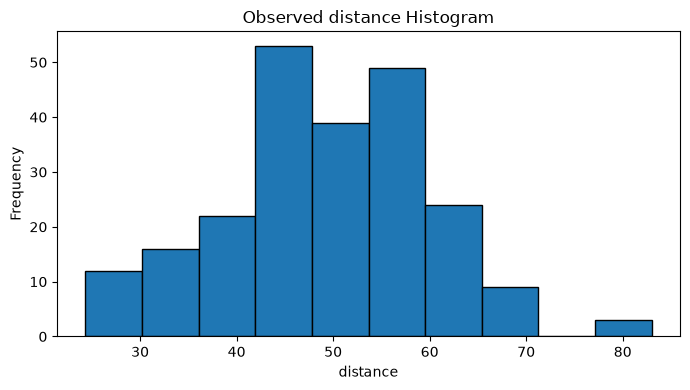

In [95]:
observed = train_df[STAT_FEATURE].dropna()

plt.figure(figsize=(7,4))
plt.hist(observed, bins=10, edgecolor="black")
plt.title(f"Observed {STAT_FEATURE} Histogram")
plt.xlabel(STAT_FEATURE)
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("outputs/figures/histogram.png", dpi=150)
plt.show()


In [96]:
print("Observed n:", len(observed))
print("Mean:", observed.mean())
print("Median:", observed.median())
print("Sample SD:", observed.std(ddof=1))

Observed n: 227
Mean: 49.50497797356828
Median: 50.18
Sample SD: 10.765823849721373


## M2 — Statistical Inference

In [97]:
from scipy import stats

g1 = train_df.loc[train_df["group"] == "G1", STAT_FEATURE].dropna()
g2 = train_df.loc[train_df["group"] == "G2", STAT_FEATURE].dropna()

t_stat, p_value = stats.ttest_ind(
    g1, g2, equal_var=False, alternative="two-sided"
)

n = len(observed)
mean = observed.mean()
sem = stats.sem(observed)
ci_low, ci_high = stats.t.interval(
    confidence=0.95,
    df=n - 1,
    loc=mean,
    scale=sem
)

print("G1 n:", len(g1), "mean:", g1.mean())
print("G2 n:", len(g2), "mean:", g2.mean())
print("t-statistic:", t_stat)
print("p-value:", p_value)
print("95% CI:", (ci_low, ci_high))

G1 n: 126 mean: 49.32230158730159
G2 n: 101 mean: 49.73287128712872
t-statistic: -0.2854077856134065
p-value: 0.775605717470789
95% CI: (np.float64(48.09694002414536), np.float64(50.9130159229912))


## M3 — Linear Algebra

In [98]:
cov_data = train_df[COV_FEATURES].dropna()

X_centered = cov_data - cov_data.mean()
cov_matrix = (X_centered.T @ X_centered) / (len(cov_data) - 1)

print("Rows used:", len(cov_data))
display(cov_matrix)

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
order = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

variance_share = eigenvalues[0] / eigenvalues.sum()

print("Eigenvalues:", eigenvalues)
print("Largest eigenvalue:", eigenvalues[0])
print("Principal variance share:", variance_share)
print("Principal direction:", eigenvectors[:, 0])

Rows used: 217


,distance,load
distance,116.220374,2.234777
load,2.234777,115.366326


Eigenvalues: [118.06855887 113.51814026]
Largest eigenvalue: 118.06855887128363
Principal variance share: 0.5098244386014535
Principal direction: [-0.77061197 -0.63730463]


# Task 2 — Data Preprocessing & Feature Engineering 

In [ ]:
# Median imputation is fitted ONLY on the 192 fit records.
imputer = SimpleImputer(strategy="median")

fit_num = pd.DataFrame(
    imputer.fit_transform(fit_df[NUMERIC_COLS]),
    columns=NUMERIC_COLS
)
val_num = pd.DataFrame(
    imputer.transform(val_df[NUMERIC_COLS]),
    columns=NUMERIC_COLS
)
test_num = pd.DataFrame(
    imputer.transform(test_df[NUMERIC_COLS]),
    columns=NUMERIC_COLS
)

fit_num["engineered_feature"] = fit_num['load'] / (fit_num['staff'] + 1)
val_num["engineered_feature"] = val_num['load'] / (val_num['staff'] + 1)
test_num["engineered_feature"] = test_num['load'] / (test_num['staff'] + 1)

MODEL_NUMERIC_COLS = NUMERIC_COLS + ["engineered_feature"]

# Scale numeric features only.
scaler = StandardScaler()
X_fit_num = scaler.fit_transform(fit_num[MODEL_NUMERIC_COLS])
X_val_num = scaler.transform(val_num[MODEL_NUMERIC_COLS])
X_test_num = scaler.transform(test_num[MODEL_NUMERIC_COLS])

# One-hot encode group, with unseen categories ignored.
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_fit_group = encoder.fit_transform(fit_df[["group"]])
X_val_group = encoder.transform(val_df[["group"]])
X_test_group = encoder.transform(test_df[["group"]])

group_names = list(encoder.get_feature_names_out(["group"]))

X_fit = np.hstack([X_fit_num, X_fit_group])
X_val = np.hstack([X_val_num, X_val_group])
X_test = np.hstack([X_test_num, X_test_group])

feature_names = MODEL_NUMERIC_COLS + group_names

print("Fit shape:", X_fit.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)
print("Features:", feature_names)

assert TARGET not in feature_names
assert "record_id" not in feature_names
assert np.isfinite(X_fit).all()
assert np.isfinite(X_val).all()
assert np.isfinite(X_test).all()


Fit shape: (192, 7)
Validation shape: (48, 7)
Test shape: (60, 7)
Features: ['distance', 'load', 'traffic', 'staff', 'engineered_feature', 'group_G1', 'group_G2']


In [100]:
import joblib

preprocessing = {
    "imputer": imputer,
    "scaler": scaler,
    "encoder": encoder,
    "feature_names": feature_names,
    "target": TARGET
}
joblib.dump(preprocessing, "models/preprocessing.joblib")
print("Saved preprocessing artifact.")

Saved preprocessing artifact.


## Task 3 — Supervised Learning

## S1 — Baseline and Classifier 


In [101]:
y_fit = fit_df[TARGET].astype(int).to_numpy()
y_val = val_df[TARGET].astype(int).to_numpy()
y_test = test_df[TARGET].astype(int).to_numpy()

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_fit, y_fit)

logistic = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logistic.fit(X_fit, y_fit)

dummy_pred = dummy.predict(X_test)
log_pred = logistic.predict(X_test)
log_prob = logistic.predict_proba(X_test)[:, 1]

## S2 — Holdout Evaluation

In [102]:
def metric_row(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0)
    }

In [103]:
metrics = pd.DataFrame([
    metric_row(y_test, dummy_pred),
    metric_row(y_test, log_pred)
], index=["DummyClassifier", "LogisticRegression"])

In [104]:
display(metrics)
metrics.to_csv("outputs/metrics/supervised_metrics.csv")

,Accuracy,Precision,Recall,F1
DummyClassifier,0.516667,0.000000,0.000000,0.000000
LogisticRegression,0.850000,0.884615,0.793103,0.836364


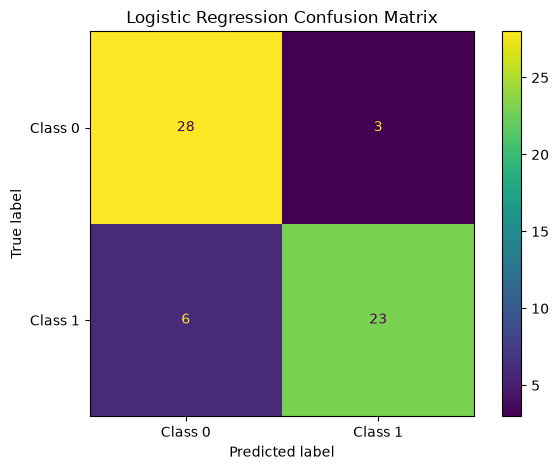

In [105]:
cm = confusion_matrix(y_test, log_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1"]
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/figures/logistic_confusion_matrix.png", dpi=150)
plt.show()

## S3 — Interpretation

In [106]:
predictions = pd.DataFrame({
    "record_id": test_df["record_id"],
    "true_label": y_test,
    "predicted_label": log_pred,
    "class_1_probability": log_prob
})
predictions.to_csv(
    "outputs/predictions/logistic_test_predictions.csv",
    index=False
)
display(predictions.head())

,record_id,true_label,predicted_label,class_1_probability
0,50,0,0,0.034625
1,231,0,0,0.074453
2,297,0,0,0.006790
3,97,0,0,0.112015
4,285,0,0,0.040311


## Task 4 — Unsupervised Learning

## U1 — K-Means and Selection

In [107]:
cluster_scores = []

for k in [2, 3, 4]:
    km = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=RANDOM_STATE
    )
    labels = km.fit_predict(X_fit_num)

    cluster_scores.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_fit_num, labels)
    })

cluster_scores = pd.DataFrame(cluster_scores)
display(cluster_scores)

cluster_scores.to_csv(
    "outputs/clustering/k_selection_scores.csv",
    index=False
)

best_silhouette = cluster_scores["silhouette"].max()
best_k = int(
    cluster_scores.loc[
        cluster_scores["silhouette"] == best_silhouette, "k"
    ].min()
)

print("Selected k:", best_k)

,k,inertia,silhouette
0,2,719.632089,0.246337
1,3,599.659398,0.207147
2,4,535.383548,0.190232


Selected k: 2


## U2 — Segment Interpretation

In [109]:
final_kmeans = KMeans(
    n_clusters=best_k,
    n_init=10,
    random_state=RANDOM_STATE
)

cluster_labels = final_kmeans.fit_predict(X_fit_num)

cluster_data = fit_num.copy()
cluster_data["cluster"] = cluster_labels

cluster_profiles = cluster_data.groupby("cluster")[MODEL_NUMERIC_COLS].mean()
display(cluster_profiles)

cluster_profiles.to_csv(
    "outputs/clustering/cluster_profiles.csv"
)

cluster_assignments = fit_df[["record_id"]].copy()
cluster_assignments["cluster"] = cluster_labels
cluster_assignments.to_csv(
    "outputs/clustering/fit_cluster_assignments.csv",
    index=False
)



,distance,load,traffic,staff,engineered_feature
cluster,,,,,
0,48.418955,47.127985,49.066269,54.035000,0.863256
1,52.869483,57.461552,49.856207,41.426724,1.372952


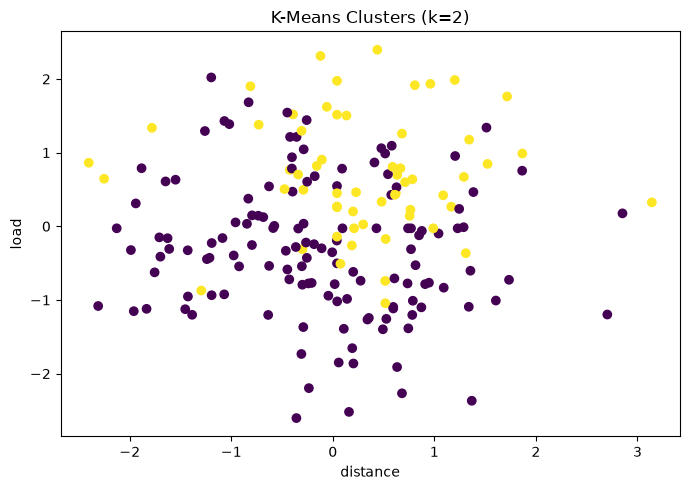

In [110]:

plt.figure(figsize=(7,5))
plt.scatter(X_fit_num[:, 0], X_fit_num[:, 1], c=cluster_labels)
plt.xlabel(MODEL_NUMERIC_COLS[0])
plt.ylabel(MODEL_NUMERIC_COLS[1])
plt.title(f"K-Means Clusters (k={best_k})")
plt.tight_layout()
plt.savefig("outputs/figures/kmeans_clusters.png", dpi=150)
plt.show()

## Task 5 — Deep Learning up to ANN 

In [111]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(RANDOM_STATE)

ann = keras.Sequential([
    keras.Input(shape=(X_fit.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

ann.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ann.summary()
print("Trainable parameters:", ann.count_params())


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145 (580.00 B)

 Trainable params: 145 (580.00 B)

 Non-trainable params: 0 (0.00 B)

Trainable parameters: 145


## D2 — Training and Validation

In [112]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = ann.fit(
    X_fit,
    y_fit,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)

pd.DataFrame(history.history).to_csv(
    "outputs/metrics/ann_training_history.csv",
    index=False
)



Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.7083 - loss: 0.6236 - val_accuracy: 0.6875 - val_loss: 0.6302
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7240 - loss: 0.6074 - val_accuracy: 0.7083 - val_loss: 0.6164
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7448 - loss: 0.5921 - val_accuracy: 0.6875 - val_loss: 0.6032
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7656 - loss: 0.5772 - val_accuracy: 0.6875 - val_loss: 0.5905
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7760 - loss: 0.5631 - val_accuracy: 0.6875 - val_loss: 0.5783
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7865 - loss: 0.5496 - val_accuracy: 0.7292 - val_loss: 0.5665
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7865 - loss: 0.5365 - val_accuracy: 0.7292 - val_loss: 0.5552
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7865 - loss: 0.5236 - val_accuracy: 0.7500 - v

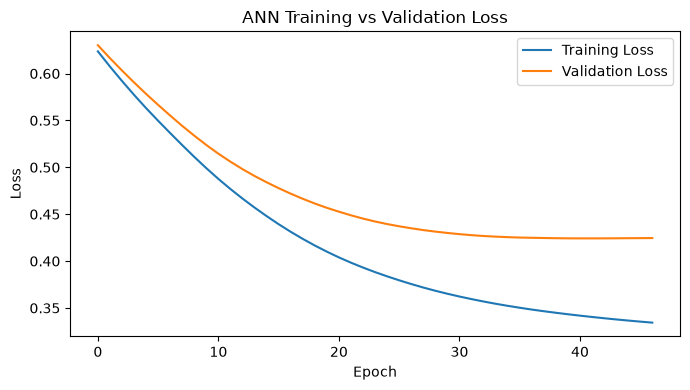

In [113]:

plt.figure(figsize=(7,4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/figures/ann_loss_curves.png", dpi=150)
plt.show()

## D3 — Comparison 

In [114]:
ann_prob = ann.predict(X_test, verbose=0).ravel()
ann_pred = (ann_prob >= 0.5).astype(int)

ann_metrics = metric_row(y_test, ann_pred)

final_comparison = pd.DataFrame(
    [metric_row(y_test, log_pred), ann_metrics],
    index=["LogisticRegression", "ANN"]
)

display(final_comparison)
final_comparison.to_csv(
    "outputs/metrics/logistic_vs_ann.csv"
)



,Accuracy,Precision,Recall,F1
LogisticRegression,0.850000,0.884615,0.793103,0.836364
ANN,0.816667,0.846154,0.758621,0.800000


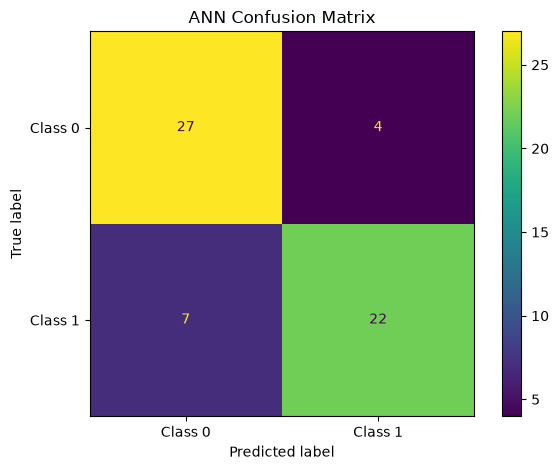

In [115]:
ann_predictions = pd.DataFrame({
    "record_id": test_df["record_id"],
    "true_label": y_test,
    "predicted_label": ann_pred,
    "class_1_probability": ann_prob
})
ann_predictions.to_csv(
    "outputs/predictions/ann_test_predictions.csv",
    index=False
)

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, ann_pred),
    display_labels=["Class 0", "Class 1"]
).plot()

plt.title("ANN Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/figures/ann_confusion_matrix.png", dpi=150)
plt.show()

In [116]:
ann.save("models/ann.keras")
joblib.dump(logistic, "models/logistic_regression.joblib")

lr_ids = pd.read_csv(
    "outputs/predictions/logistic_test_predictions.csv"
)["record_id"].tolist()

ann_ids = pd.read_csv(
    "outputs/predictions/ann_test_predictions.csv"
)["record_id"].tolist()